# Analisis Sentimen untuk Mengidentifikasi Persepsi dan Kualitas Layanan Aplikasi Shopee Berdasarkan Ulasan Pengguna di Google Play Store

---
**Dataset:** `shopee_reviews_2000.csv` — 2.000 ulasan dari Google Play Store  
**Kolom:** `review` (teks ulasan), `rating` (1–5), `tanggal`  
**Metode:** Text Preprocessing → TF-IDF / Word2Vec → Machine Learning (Naive Bayes, SVM, LSTM)  
**Minggu:** 1 – 12

---


---
##  MINGGU 1 — Inisiasi & Eksplorasi Dataset Awal
**Tujuan:** Memahami struktur dataset, melakukan eksplorasi awal, dan menentukan arah penelitian.


In [2]:
# Install library yang diperlukan (jalankan sekali)
# !pip install pandas numpy matplotlib seaborn wordcloud scikit-learn nltk Sastrawi imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" Library berhasil diimport")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")


 Library berhasil diimport
pandas  : 2.2.3
numpy   : 2.1.3


In [3]:
# Load dataset
df = pd.read_csv('shopee_reviews_2000.csv')

print("=" * 50)
print(" INFO DATASET")
print("=" * 50)
print(f"Jumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")
print(f"Nama kolom      : {df.columns.tolist()}")
print()
print(df.head(10))


 INFO DATASET
Jumlah baris    : 2000
Jumlah kolom    : 3
Nama kolom      : ['review', 'rating', 'tanggal']

                                              review  rating  \
0                                             mantap       5   
1                                       bgus siip lh       5   
2                     apeli kasih tidak bisa di buka       3   
3                                    dangat menyesal       1   
4  knp pembekuan paylater sy sdh 1 THN LBH msh di...       5   
5  Puas dan Senang berbelanja di Shopee... Shopee...       5   
6          iklan shopee di apk lain maksa banget anj       1   
7                          murahhh murah barangg nyy       4   
8  memudahkan untk belanja kebutuhan hari"... tri...       5   
9                                 aplikasi nya bagus       1   

               tanggal  
0  2026-04-15 03:58:37  
1  2026-04-15 03:55:54  
2  2026-04-15 03:55:02  
3  2026-04-15 03:51:37  
4  2026-04-15 03:50:53  
5  2026-04-15 03:49:10  
6  2026-04-1

In [4]:
# Tipe data dan info dasar
print(df.info())
print()
print(" Statistik Deskriptif:")
print(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   review   2000 non-null   object
 1   rating   2000 non-null   int64 
 2   tanggal  2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB
None

 Statistik Deskriptif:
       review       rating              tanggal
count    2000  2000.000000                 2000
unique   1680          NaN                 1989
top     bagus          NaN  2026-04-14 11:56:36
freq       57          NaN                    2
mean      NaN     3.896000                  NaN
std       NaN     1.666905                  NaN
min       NaN     1.000000                  NaN
25%       NaN     2.000000                  NaN
50%       NaN     5.000000                  NaN
75%       NaN     5.000000                  NaN
max       NaN     5.000000                  NaN


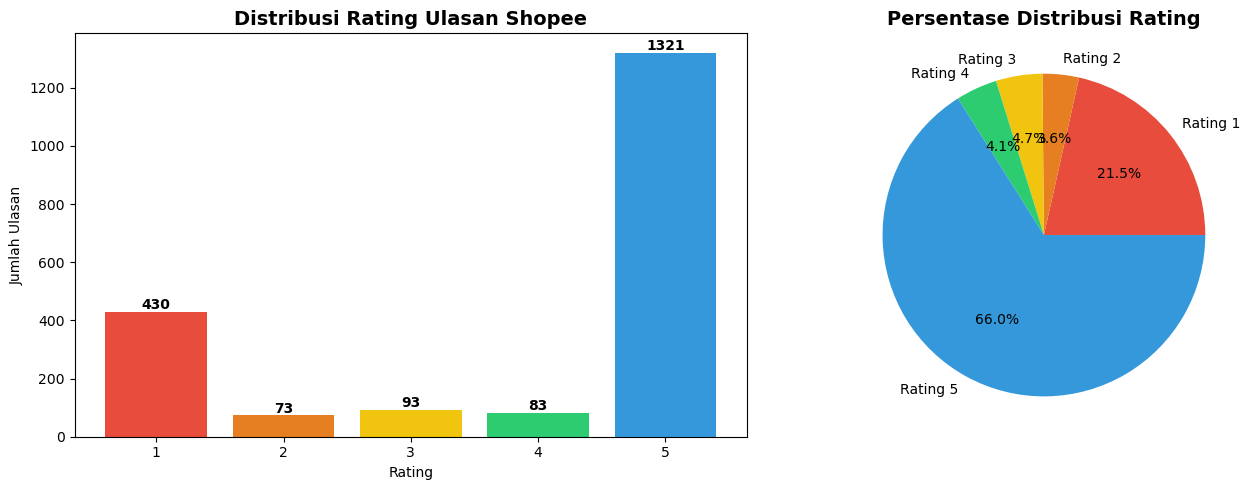

Gambar disimpan: minggu1_distribusi_rating.png


In [5]:
# Distribusi Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Distribusi Rating Ulasan Shopee', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah Ulasan')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'Rating {i}' for i in rating_counts.index],
            autopct='%1.1f%%', colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[1].set_title('Persentase Distribusi Rating', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('minggu1_distribusi_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gambar disimpan: minggu1_distribusi_rating.png")


 Statistik Panjang Teks Ulasan:
       panjang_review  jumlah_kata
count         2000.00      2000.00
mean            76.29        12.05
std             98.57        15.61
min              1.00         1.00
25%             12.00         2.00
50%             38.00         6.00
75%             96.00        15.00
max            500.00        96.00


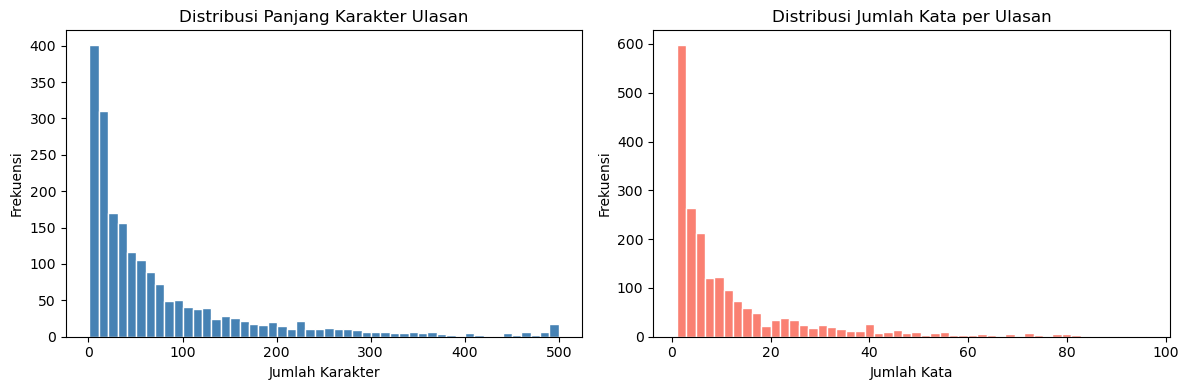

In [6]:
# Distribusi panjang teks ulasan
df['panjang_review'] = df['review'].apply(lambda x: len(str(x)))
df['jumlah_kata'] = df['review'].apply(lambda x: len(str(x).split()))

print(" Statistik Panjang Teks Ulasan:")
print(df[['panjang_review','jumlah_kata']].describe().round(2))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['panjang_review'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Panjang Karakter Ulasan')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
plt.hist(df['jumlah_kata'], bins=50, color='salmon', edgecolor='white')
plt.title('Distribusi Jumlah Kata per Ulasan')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('minggu1_distribusi_panjang.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 2 — Labeling Sentimen & Data Profiling
**Tujuan:** Membuat label sentimen berdasarkan rating, analisis profil data (duplikat, noise, distribusi kelas).


In [7]:
# Labeling sentimen berdasarkan rating
# Rating 4-5 = Positif, Rating 3 = Netral, Rating 1-2 = Negatif
def labeling_sentimen(rating):
    if rating >= 4:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentimen'] = df['rating'].apply(labeling_sentimen)

print(" Distribusi Label Sentimen:")
print(df['sentimen'].value_counts())
print()
print(df['sentimen'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


 Distribusi Label Sentimen:
sentimen
Positif    1404
Negatif     503
Netral       93
Name: count, dtype: int64

sentimen
Positif     70.2%
Negatif    25.15%
Netral      4.65%
Name: proportion, dtype: object


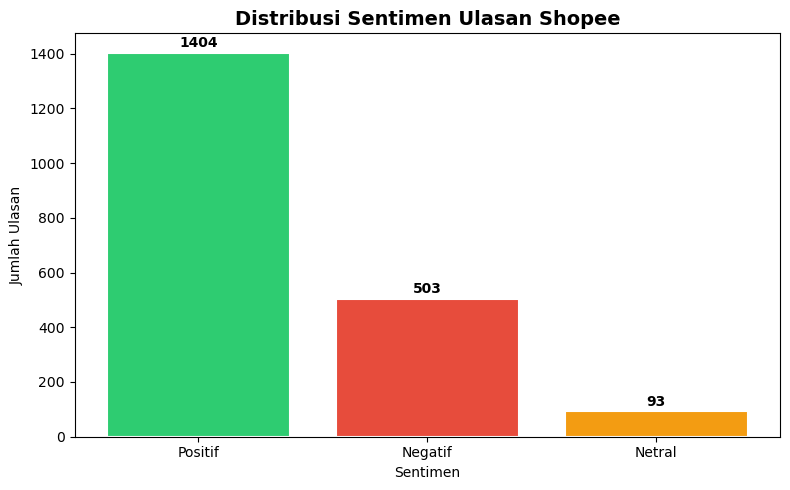

In [8]:
# Visualisasi distribusi sentimen
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}
counts = df['sentimen'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[colors[s] for s in counts.index], edgecolor='white', linewidth=1.5)
ax.set_title('Distribusi Sentimen Ulasan Shopee', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah Ulasan')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{bar.get_height()}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('minggu2_distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# Data Profiling: Cek duplikat, nilai kosong, noise
print(" DATA PROFILING")
print(f"Total data           : {len(df)}")
print(f"Data duplikat (review): {df['review'].duplicated().sum()}")
print(f"Nilai kosong (review) : {df['review'].isnull().sum()}")
print(f"Nilai kosong (rating) : {df['rating'].isnull().sum()}")
print()

# Cek review yang sangat pendek (noise)
short_reviews = df[df['jumlah_kata'] <= 1]
print(f"Ulasan sangat pendek (≤1 kata): {len(short_reviews)}")
print("Contoh:")
print(short_reviews['review'].head(10).tolist())


 DATA PROFILING
Total data           : 2000
Data duplikat (review): 320
Nilai kosong (review) : 0
Nilai kosong (rating) : 0

Ulasan sangat pendek (≤1 kata): 366
Contoh:
['mantap', 'ol', 'bagus', 'lemottt', 'mantap.', 'puas', 'Ok', 'bagus', 'baik', 'good']


 Rentang Waktu Data:
Tanggal terlama  : 2026-04-12 14:30:32
Tanggal terbaru  : 2026-04-15 03:58:37


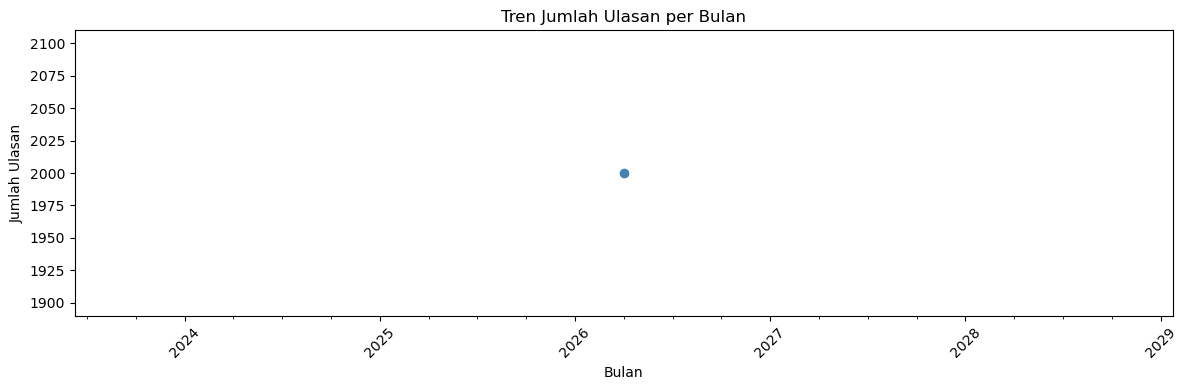

In [10]:
# Analisis kolom tanggal
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['bulan'] = df['tanggal'].dt.to_period('M')

print(" Rentang Waktu Data:")
print(f"Tanggal terlama  : {df['tanggal'].min()}")
print(f"Tanggal terbaru  : {df['tanggal'].max()}")

# Trend ulasan per bulan
trend = df.groupby('bulan').size()
plt.figure(figsize=(12, 4))
trend.plot(kind='line', marker='o', color='steelblue')
plt.title('Tren Jumlah Ulasan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('minggu2_tren_ulasan.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 3 — Text Preprocessing: Case Folding, Cleaning & Tokenisasi
**Tujuan:** Membersihkan teks dari noise (URL, angka, emoji, karakter khusus) dan melakukan tokenisasi.


In [11]:
import re
import string

def case_folding(text):
    """Mengubah teks menjadi huruf kecil semua"""
    return str(text).lower()

def hapus_noise(text):
    """Menghapus URL, mention, hashtag, angka, emoji, dan karakter khusus"""
    text = re.sub(r'http\S+|www\.\S+', '', text)       # Hapus URL
    text = re.sub(r'@\w+', '', text)                    # Hapus mention
    text = re.sub(r'#\w+', '', text)                    # Hapus hashtag
    text = re.sub(r'\d+', '', text)                     # Hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)               # Hapus tanda baca
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)         # Hapus emoji/karakter non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()            # Hapus spasi berlebih
    return text

def tokenisasi(text):
    """Memecah teks menjadi token/kata"""
    return text.split()

# Terapkan preprocessing bertahap
df['review_lower'] = df['review'].apply(case_folding)
df['review_clean'] = df['review_lower'].apply(hapus_noise)
df['tokens'] = df['review_clean'].apply(tokenisasi)

print("Contoh Hasil Preprocessing:")
for i in range(5):
    print(f"\nOriginal  : {df['review'].iloc[i]}")
    print(f"Lower     : {df['review_lower'].iloc[i]}")
    print(f"Clean     : {df['review_clean'].iloc[i]}")
    print(f"Tokens    : {df['tokens'].iloc[i]}")


Contoh Hasil Preprocessing:

Original  : mantap
Lower     : mantap
Clean     : mantap
Tokens    : ['mantap']

Original  : bgus siip lh
Lower     : bgus siip lh
Clean     : bgus siip lh
Tokens    : ['bgus', 'siip', 'lh']

Original  : apeli kasih tidak bisa di buka
Lower     : apeli kasih tidak bisa di buka
Clean     : apeli kasih tidak bisa di buka
Tokens    : ['apeli', 'kasih', 'tidak', 'bisa', 'di', 'buka']

Original  : dangat menyesal
Lower     : dangat menyesal
Clean     : dangat menyesal
Tokens    : ['dangat', 'menyesal']

Original  : knp pembekuan paylater sy sdh 1 THN LBH msh dibekukan...
Lower     : knp pembekuan paylater sy sdh 1 thn lbh msh dibekukan...
Clean     : knp pembekuan paylater sy sdh thn lbh msh dibekukan
Tokens    : ['knp', 'pembekuan', 'paylater', 'sy', 'sdh', 'thn', 'lbh', 'msh', 'dibekukan']


📊 Perbandingan Jumlah Kata (Sebelum vs Sesudah Cleaning):
Rata-rata kata SEBELUM : 12.05
Rata-rata kata SESUDAH : 12.03


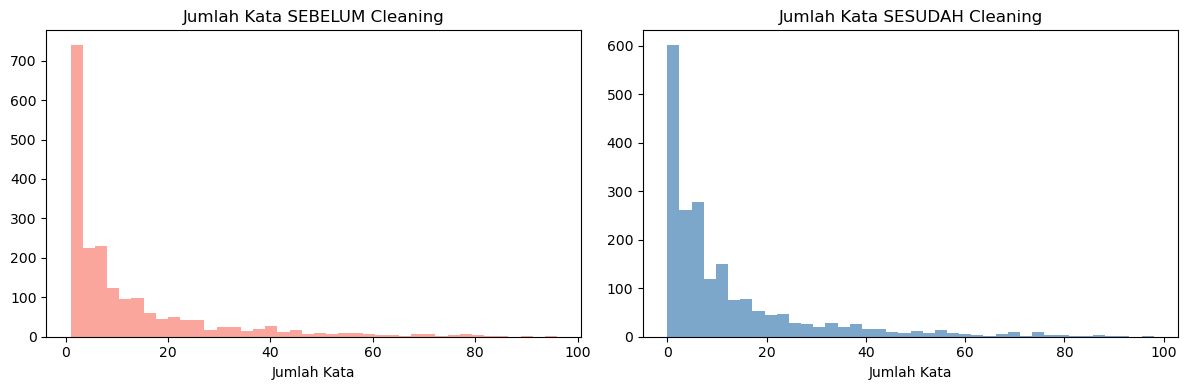

In [12]:
# Statistik sebelum vs sesudah cleaning
df['jumlah_kata_bersih'] = df['tokens'].apply(len)

print("📊 Perbandingan Jumlah Kata (Sebelum vs Sesudah Cleaning):")
print(f"Rata-rata kata SEBELUM : {df['jumlah_kata'].mean():.2f}")
print(f"Rata-rata kata SESUDAH : {df['jumlah_kata_bersih'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['jumlah_kata'], bins=40, color='salmon', alpha=0.7, label='Sebelum')
axes[0].set_title('Jumlah Kata SEBELUM Cleaning')
axes[0].set_xlabel('Jumlah Kata')
axes[1].hist(df['jumlah_kata_bersih'], bins=40, color='steelblue', alpha=0.7, label='Sesudah')
axes[1].set_title('Jumlah Kata SESUDAH Cleaning')
axes[1].set_xlabel('Jumlah Kata')
plt.tight_layout()
plt.savefig('minggu3_sebelum_sesudah_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 4 — Normalisasi Slang & Stopword Removal
**Tujuan:** Menormalisasi kata gaul/slang bahasa Indonesia dan menghapus kata-kata tidak bermakna (stopword).


In [13]:
# Kamus normalisasi kata slang/gaul Indonesia
slang_dict = {
    'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak', 'tdk': 'tidak',
    'nggak': 'tidak', 'ngga': 'tidak', 'kagak': 'tidak',
    'yg': 'yang', 'krn': 'karena', 'karna': 'karena',
    'utk': 'untuk', 'tuk': 'untuk', 'buat': 'untuk',
    'dg': 'dengan', 'dgn': 'dengan', 'sama': 'dengan',
    'sy': 'saya', 'aq': 'saya', 'ak': 'saya', 'gue': 'saya', 'gw': 'saya',
    'lo': 'kamu', 'lu': 'kamu',
    'bgt': 'banget', 'bngt': 'banget', 'banget': 'sangat',
    'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah',
    'blm': 'belum', 'belom': 'belum',
    'aja': 'saja', 'doang': 'saja',
    'tp': 'tapi', 'tapi': 'tetapi',
    'bs': 'bisa', 'bsa': 'bisa',
    'msh': 'masih',
    'lg': 'lagi',
    'dr': 'dari',
    'hrs': 'harus',
    'jg': 'juga',
    'dll': 'dan lain lain',
    'brp': 'berapa',
    'kmrn': 'kemarin',
    'td': 'tadi',
    'lbh': 'lebih',
    'sdkt': 'sedikit',
    'byk': 'banyak',
    'mau': 'ingin',
    'kmn': 'kemana',
    'smpe': 'sampai', 'sampe': 'sampai',
    'knp': 'kenapa', 'knapa': 'kenapa',
    'gimana': 'bagaimana', 'gmn': 'bagaimana',
    'pdhl': 'padahal',
    'emg': 'memang', 'emang': 'memang',
    'bener': 'benar', 'bner': 'benar',
    'nanya': 'bertanya', 'nanyak': 'bertanya',
    'mantap': 'bagus', 'mantul': 'bagus', 'keren': 'bagus',
    'jelek': 'buruk', 'parah': 'buruk', 'ancur': 'rusak',
    'nyebelin': 'menjengkelkan', 'nyebelin': 'menjengkelkan',
    'ribet': 'rumit',
    'lemot': 'lambat',
}

def normalisasi_slang(tokens):
    """Mengganti kata slang dengan kata baku"""
    return [slang_dict.get(word, word) for word in tokens]

df['tokens_normalized'] = df['tokens'].apply(normalisasi_slang)

# Contoh hasil normalisasi
print("Contoh Normalisasi Slang:")
for i in range(5):
    orig = df['tokens'].iloc[i]
    norm = df['tokens_normalized'].iloc[i]
    if orig != norm:
        print(f"Asli       : {orig}")
        print(f"Dinormalisasi: {norm}")
        print()


Contoh Normalisasi Slang:
Asli       : ['mantap']
Dinormalisasi: ['bagus']

Asli       : ['knp', 'pembekuan', 'paylater', 'sy', 'sdh', 'thn', 'lbh', 'msh', 'dibekukan']
Dinormalisasi: ['kenapa', 'pembekuan', 'paylater', 'saya', 'sudah', 'thn', 'lebih', 'masih', 'dibekukan']



In [14]:
# Stopword Removal menggunakan daftar manual (+ tambahan domain)
stopwords_id = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'tidak', 'ada', 'juga', 'sudah', 'dalam', 'saya',
    'kami', 'kita', 'mereka', 'anda', 'kamu', 'ia', 'dia', 'belum',
    'akan', 'bisa', 'dapat', 'harus', 'oleh', 'atau', 'jika', 'karena',
    'maka', 'lebih', 'namun', 'tetapi', 'hal', 'saat', 'ketika', 'lagi',
    'kalau', 'selalu', 'masih', 'agar', 'supaya', 'menjadi', 'bagi',
    'apa', 'siapa', 'bagaimana', 'kenapa', 'dimana', 'kemana', 'kapan',
    'pun', 'pula', 'pernah', 'sama', 'sangat', 'sekali', 'saja', 'sana',
    'sini', 'situ', 'satu', 'dua', 'tiga', 'dan', 'lah', 'kah',
    'app', 'aplikasi', 'shopee', 'google', 'play', 'store',
])

def hapus_stopword(tokens):
    return [t for t in tokens if t not in stopwords_id and len(t) > 1]

df['tokens_final'] = df['tokens_normalized'].apply(hapus_stopword)

print("Contoh Hasil Stopword Removal:")
for i in range(5):
    print(f"Normalized : {df['tokens_normalized'].iloc[i]}")
    print(f"Final      : {df['tokens_final'].iloc[i]}")
    print()


Contoh Hasil Stopword Removal:
Normalized : ['bagus']
Final      : ['bagus']

Normalized : ['bgus', 'siip', 'lh']
Final      : ['bgus', 'siip', 'lh']

Normalized : ['apeli', 'kasih', 'tidak', 'bisa', 'di', 'buka']
Final      : ['apeli', 'kasih', 'buka']

Normalized : ['dangat', 'menyesal']
Final      : ['dangat', 'menyesal']

Normalized : ['kenapa', 'pembekuan', 'paylater', 'saya', 'sudah', 'thn', 'lebih', 'masih', 'dibekukan']
Final      : ['pembekuan', 'paylater', 'thn', 'dibekukan']



---
##  MINGGU 5 — Stemming & Frekuensi Kata
**Tujuan:** Melakukan stemming (mengubah kata ke bentuk dasar) dan analisis frekuensi kata per sentimen.


In [15]:
# Stemming menggunakan Sastrawi
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    SASTRAWI_AVAILABLE = True
    print(" Sastrawi tersedia, menggunakan Stemming Sastrawi")
except ImportError:
    SASTRAWI_AVAILABLE = False
    print(" Sastrawi tidak tersedia. Menggunakan manual simple stemming.")
    print("   Jalankan: pip install PySastrawi")

def simple_stem(word):
    """Stemming manual sederhana (fallback tanpa Sastrawi)"""
    prefixes = ['me', 'ber', 'ke', 'ter', 'pe', 'se', 'di', 'meng', 'per', 'mem']
    suffixes = ['kan', 'an', 'nya', 'lah', 'kah', 'in', 'i']
    w = word
    for p in prefixes:
        if w.startswith(p) and len(w) > len(p) + 3:
            w = w[len(p):]
            break
    for s in suffixes:
        if w.endswith(s) and len(w) > len(s) + 3:
            w = w[:-len(s)]
            break
    return w

def stem_tokens(tokens):
    if SASTRAWI_AVAILABLE:
        return [stemmer.stem(t) for t in tokens]
    else:
        return [simple_stem(t) for t in tokens]

df['tokens_stem'] = df['tokens_final'].apply(stem_tokens)

print("Contoh Hasil Stemming:")
for i in range(5):
    print(f"Sebelum Stem: {df['tokens_final'].iloc[i]}")
    print(f"Setelah Stem: {df['tokens_stem'].iloc[i]}")
    print()


 Sastrawi tersedia, menggunakan Stemming Sastrawi
Contoh Hasil Stemming:
Sebelum Stem: ['bagus']
Setelah Stem: ['bagus']

Sebelum Stem: ['bgus', 'siip', 'lh']
Setelah Stem: ['bgus', 'siip', 'lh']

Sebelum Stem: ['apeli', 'kasih', 'buka']
Setelah Stem: ['apel', 'kasih', 'buka']

Sebelum Stem: ['dangat', 'menyesal']
Setelah Stem: ['dangat', 'sesal']

Sebelum Stem: ['pembekuan', 'paylater', 'thn', 'dibekukan']
Setelah Stem: ['beku', 'paylater', 'thn', 'beku']



In [39]:
from collections import Counter

# Frekuensi kata global
all_words = [w for tokens in df['tokens_stem'] for w in tokens]
word_freq = Counter(all_words)

print(" 50 Kata Paling Sering Muncul:")
top50 = word_freq.most_common(50)
for word, count in top50:
    print(f"  {word:20s}: {count}")


 50 Kata Paling Sering Muncul:
  bagus               : 443
  nya                 : 303
  barang              : 294
  belanja             : 272
  kirim               : 214
  baik                : 175
  lama                : 169
  banyak              : 165
  kurir               : 151
  bantu               : 139
  sampai              : 135
  pesan               : 129
  mudah               : 121
  paket               : 120
  padahal             : 111
  beli                : 111
  ingin               : 108
  jadi                : 103
  layan               : 103
  iklan               : 102
  hari                : 98
  sekarang            : 94
  makin               : 92
  tolong              : 91
  malah               : 88
  murah               : 86
  puas                : 85
  suka                : 81
  harga               : 80
  aku                 : 78
  sesuai              : 76
  kecewa              : 75
  cepat               : 73
  lain                : 72
  ya                  : 72
  ke

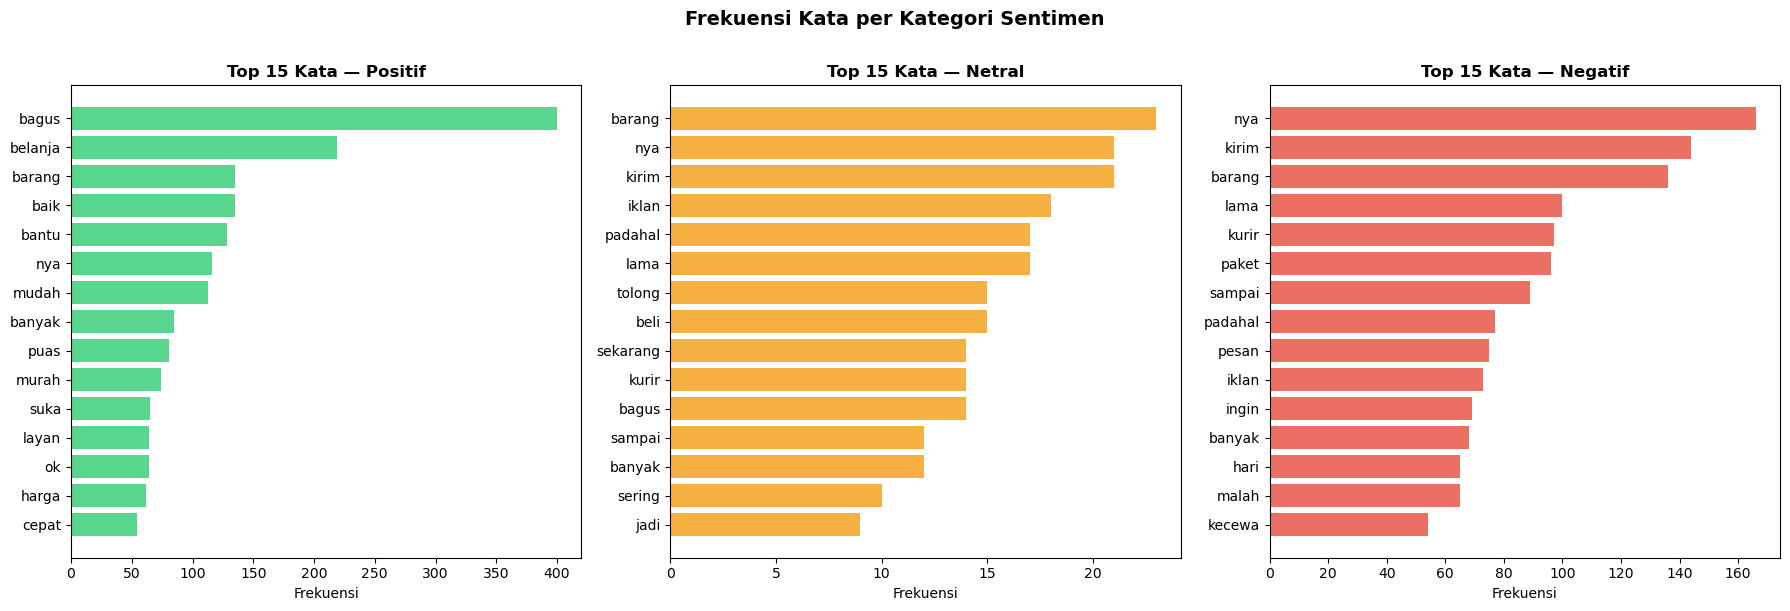

In [40]:
# Frekuensi kata per sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentimen_list = ['Positif', 'Netral', 'Negatif']
colors_bar = ['#2ecc71', '#f39c12', '#e74c3c']

for idx, (sent, color) in enumerate(zip(sentimen_list, colors_bar)):
    subset = df[df['sentimen'] == sent]
    words = [w for tokens in subset['tokens_stem'] for w in tokens]
    freq = Counter(words).most_common(15)
    words_top = [x[0] for x in freq]
    counts_top = [x[1] for x in freq]
    
    axes[idx].barh(words_top[::-1], counts_top[::-1], color=color, alpha=0.8)
    axes[idx].set_title(f'Top 15 Kata — {sent}', fontweight='bold')
    axes[idx].set_xlabel('Frekuensi')

plt.suptitle('Frekuensi Kata per Kategori Sentimen', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('minggu5_frekuensi_kata_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 6 — Word Cloud & Analisis Teks Mendalam
**Tujuan:** Visualisasi word cloud per sentimen dan identifikasi topik/aspek yang sering dikeluhkan.


 WordCloud tersedia


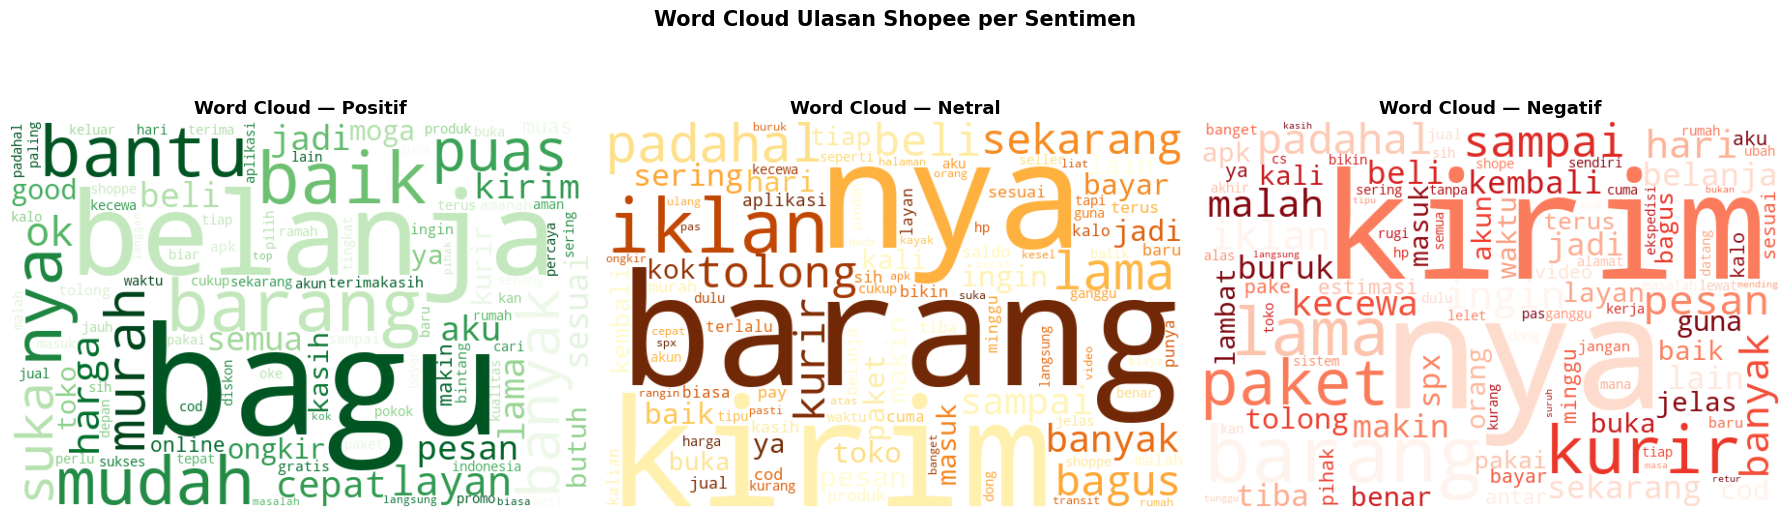

In [51]:
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
    print(" WordCloud tersedia")
except ImportError:
    WC_AVAILABLE = False
    print(" WordCloud tidak tersedia. Jalankan: pip install wordcloud")

if WC_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sentimen_list = ['Positif', 'Netral', 'Negatif']
    colormaps = ['Greens', 'YlOrBr', 'Reds']
    
    for idx, (sent, cmap) in enumerate(zip(sentimen_list, colormaps)):
        subset = df[df['sentimen'] == sent]
        text = ' '.join([' '.join(tokens) for tokens in subset['tokens_stem']])
        
        if len(text.strip()) > 0:
            wc = WordCloud(width=600, height=400, background_color='white',
                           colormap=cmap, max_words=100,
                           collocations=False).generate(text)
            axes[idx].imshow(wc, interpolation='bilinear')
            axes[idx].axis('off')
            axes[idx].set_title(f'Word Cloud — {sent}', fontsize=13, fontweight='bold')
        else:
            axes[idx].text(0.5, 0.5, 'Tidak ada data', ha='center', va='center')
            axes[idx].set_title(f'Word Cloud — {sent}', fontsize=13, fontweight='bold')
    
    plt.suptitle('Word Cloud Ulasan Shopee per Sentimen', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('minggu6_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # Alternatif: Tampilkan bar chart frekuensi
    print("Menampilkan bar chart sebagai alternatif word cloud...")
    from collections import Counter
    all_words = [w for tokens in df['tokens_stem'] for w in tokens]
    top30 = Counter(all_words).most_common(30)
    plt.figure(figsize=(12, 6))
    plt.barh([x[0] for x in top30][::-1], [x[1] for x in top30][::-1], color='steelblue')
    plt.title('Top 30 Kata Terbanyak (Semua Sentimen)')
    plt.xlabel('Frekuensi')
    plt.tight_layout()
    plt.savefig('minggu6_top30_kata.png', dpi=150, bbox_inches='tight')
    plt.show()


Pengiriman      :  412 ulasan | {'Negatif': 213, 'Positif': 160, 'Netral': 39}
Produk          :  530 ulasan | {'Positif': 379, 'Negatif': 118, 'Netral': 33}
Harga           :  183 ulasan | {'Positif': 137, 'Negatif': 38, 'Netral': 8}
Aplikasi        :  257 ulasan | {'Negatif': 131, 'Positif': 110, 'Netral': 16}
Layanan CS      :   91 ulasan | {'Negatif': 57, 'Positif': 32, 'Netral': 2}
Penjual         :  155 ulasan | {'Positif': 87, 'Negatif': 57, 'Netral': 11}
Pembayaran      :  115 ulasan | {'Negatif': 67, 'Positif': 37, 'Netral': 11}


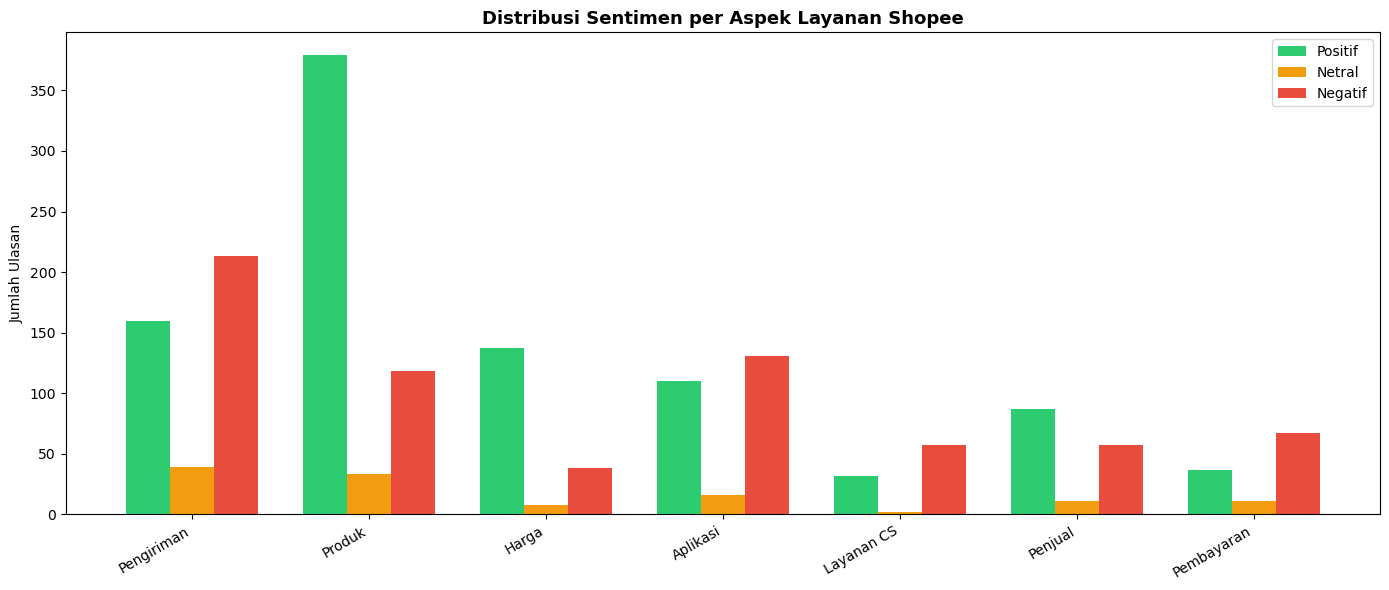

In [19]:
# Analisis Aspek: Identifikasi keluhan/pujian berdasarkan kata kunci
aspek_keywords = {
    'Pengiriman'    : ['kirim', 'kurir', 'ekspedisi', 'paket', 'tiba', 'sampai', 'lama', 'cepat'],
    'Produk'        : ['barang', 'produk', 'kualitas', 'original', 'palsu', 'rusak', 'bagus'],
    'Harga'         : ['harga', 'mahal', 'murah', 'promo', 'diskon', 'voucher', 'cashback'],
    'Aplikasi'      : ['aplikasi', 'error', 'crash', 'loading', 'lambat', 'lemot', 'bug', 'update'],
    'Layanan CS'    : ['cs', 'customer', 'service', 'respon', 'jawab', 'komplain', 'bantuan'],
    'Penjual'       : ['penjual', 'seller', 'toko', 'respon', 'amanah', 'jujur', 'tipu'],
    'Pembayaran'    : ['bayar', 'transfer', 'refund', 'pengembalian', 'dana', 'paylater', 'kredit'],
}

aspek_sentimen = {}
for aspek, keywords in aspek_keywords.items():
    mask = df['review_clean'].apply(lambda x: any(kw in x for kw in keywords))
    subset = df[mask]
    if len(subset) > 0:
        aspek_sentimen[aspek] = subset['sentimen'].value_counts().to_dict()
        print(f"{aspek:15s} : {len(subset):4d} ulasan | {subset['sentimen'].value_counts().to_dict()}")

# Visualisasi aspek
aspek_names = list(aspek_sentimen.keys())
positif_vals = [aspek_sentimen[a].get('Positif', 0) for a in aspek_names]
netral_vals  = [aspek_sentimen[a].get('Netral',  0) for a in aspek_names]
negatif_vals = [aspek_sentimen[a].get('Negatif', 0) for a in aspek_names]

x = np.arange(len(aspek_names))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, positif_vals, width, label='Positif', color='#2ecc71')
ax.bar(x,         netral_vals,  width, label='Netral',  color='#f39c12')
ax.bar(x + width, negatif_vals, width, label='Negatif', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(aspek_names, rotation=30, ha='right')
ax.set_title('Distribusi Sentimen per Aspek Layanan Shopee', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Ulasan')
ax.legend()
plt.tight_layout()
plt.savefig('minggu6_aspek_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 7 — Feature Extraction: TF-IDF
**Tujuan:** Mengubah teks menjadi representasi numerik menggunakan TF-IDF (Term Frequency-Inverse Document Frequency).


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Gabungkan token menjadi string untuk TF-IDF
df['text_final'] = df['tokens_stem'].apply(lambda x: ' '.join(x))

# Hapus baris dengan teks kosong
df_model = df[df['text_final'].str.strip() != ''].copy()
print(f"Data untuk modeling: {len(df_model)} baris")
print(f"Distribusi sentimen:\n{df_model['sentimen'].value_counts()}")


Data untuk modeling: 1976 baris
Distribusi sentimen:
sentimen
Positif    1382
Negatif     503
Netral       91
Name: count, dtype: int64


In [21]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # Unigram + Bigram
    min_df=2,             # Kata harus muncul minimal di 2 dokumen
    max_df=0.95,          # Abaikan kata yang muncul di >95% dokumen
    sublinear_tf=True     # Gunakan log TF scaling
)

X = tfidf.fit_transform(df_model['text_final'])
print(f"Dimensi matriks TF-IDF: {X.shape}")
print(f"Jumlah fitur (vocabulary): {len(tfidf.vocabulary_)}")

# Label encoding
le = LabelEncoder()
y = le.fit_transform(df_model['sentimen'])
print(f"\nLabel classes: {le.classes_}")
print(f"Encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Dimensi matriks TF-IDF: (1976, 2348)
Jumlah fitur (vocabulary): 2348

Label classes: ['Negatif' 'Netral' 'Positif']
Encoded: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}


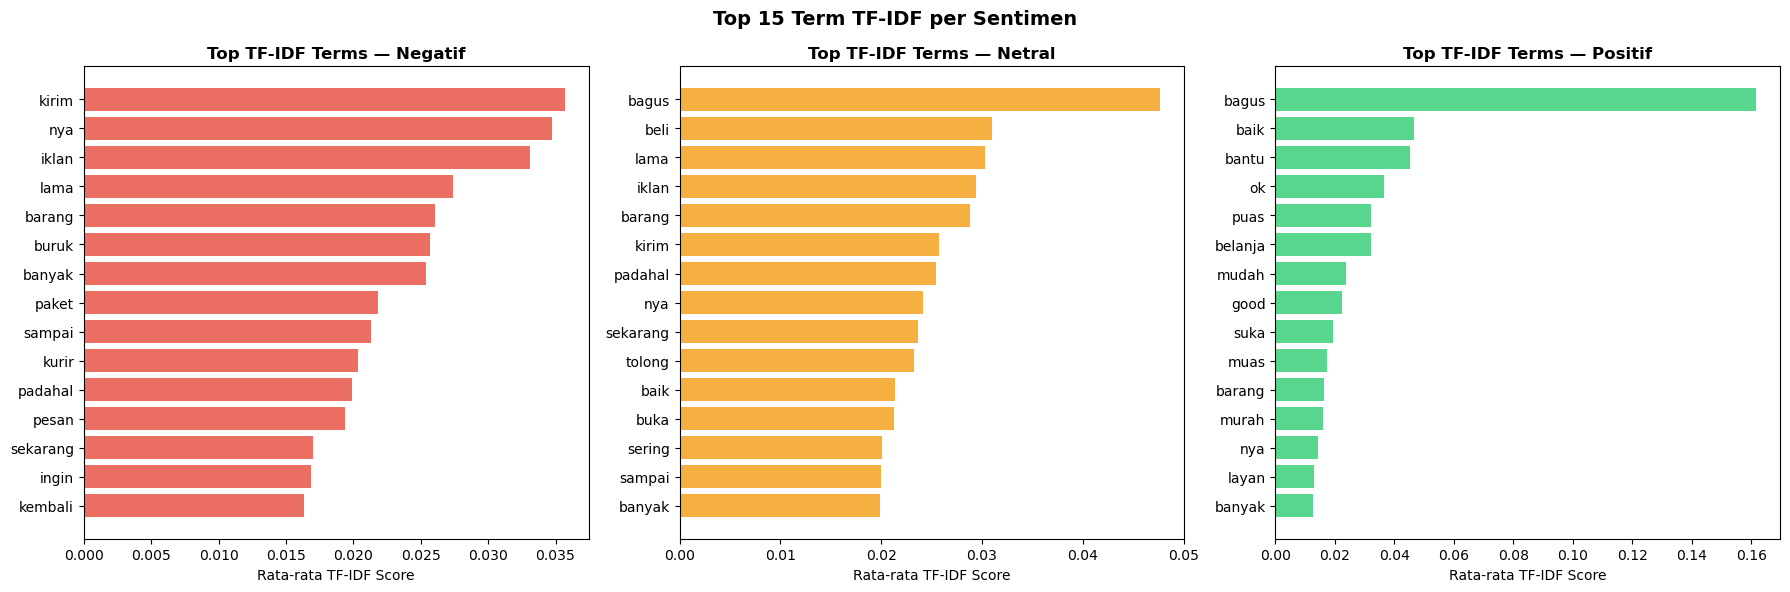

In [22]:
# Visualisasi TF-IDF: Top term per sentimen
feature_names = tfidf.get_feature_names_out()
X_dense = X.toarray()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, sent in enumerate(['Negatif', 'Netral', 'Positif']):
    mask = df_model['sentimen'] == sent
    avg_tfidf = X_dense[mask].mean(axis=0)
    top_indices = avg_tfidf.argsort()[-15:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    top_scores = [avg_tfidf[i] for i in top_indices]
    
    colors_m = {'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}
    axes[idx].barh(top_terms[::-1], top_scores[::-1], color=colors_m[sent], alpha=0.8)
    axes[idx].set_title(f'Top TF-IDF Terms — {sent}', fontweight='bold')
    axes[idx].set_xlabel('Rata-rata TF-IDF Score')

plt.suptitle('Top 15 Term TF-IDF per Sentimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('minggu7_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 8 — Split Data & Penanganan Imbalance (SMOTE)
**Tujuan:** Membagi data training/testing, menangani ketidakseimbangan kelas dengan oversampling.


In [42]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" Distribusi Data:")
print(f"Total data   : {X.shape[0]}")
print(f"Training set : {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Testing set  : {X_test.shape[0]}  ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print("\nDistribusi kelas di training set:")
for cls, lbl in zip(le.classes_, np.bincount(y_train)):
    print(f"  {cls}: {lbl}")
print("\nDistribusi kelas di testing set:")
for cls, lbl in zip(le.classes_, np.bincount(y_test)):
    print(f"  {cls}: {lbl}")


 Distribusi Data:
Total data   : 1976
Training set : 1580 (80.0%)
Testing set  : 396  (20.0%)

Distribusi kelas di training set:
  Negatif: 402
  Netral: 73
  Positif: 1105

Distribusi kelas di testing set:
  Negatif: 101
  Netral: 18
  Positif: 277


 SMOTE berhasil diterapkan

Distribusi kelas SETELAH SMOTE:
  Negatif: 1105
  Netral: 1105
  Positif: 1105


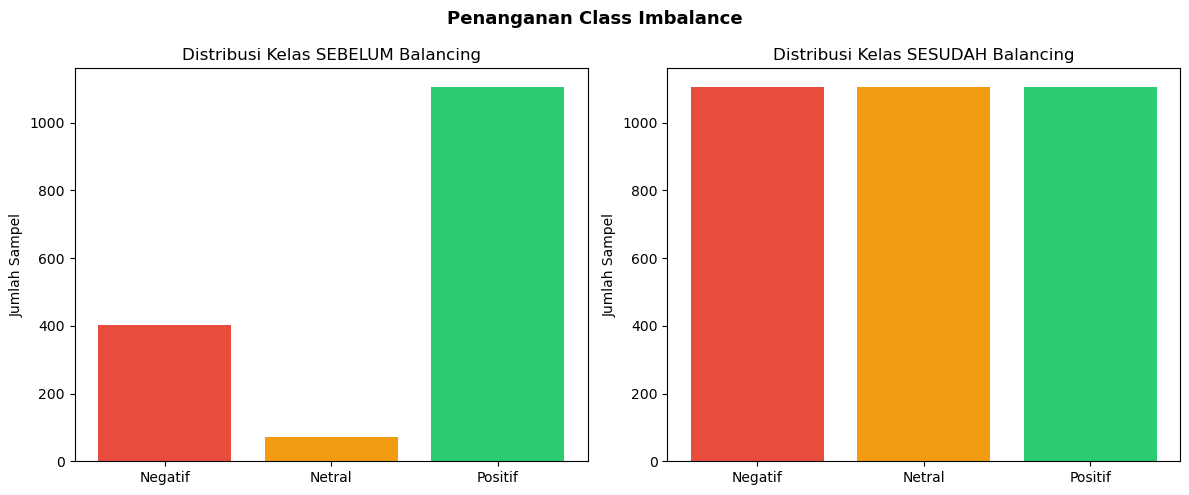

In [43]:
# Penanganan Imbalance dengan SMOTE (jika tersedia)
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=min(4, min(np.bincount(y_train))-1))
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(" SMOTE berhasil diterapkan")
    print("\nDistribusi kelas SETELAH SMOTE:")
    for cls, lbl in zip(le.classes_, np.bincount(y_train_res)):
        print(f"  {cls}: {lbl}")
except ImportError:
    print(" imbalanced-learn tidak tersedia. Menggunakan class_weight='balanced'.")
    X_train_res, y_train_res = X_train, y_train
except Exception as e:
    print(f" SMOTE gagal: {e}. Menggunakan data asli.")
    X_train_res, y_train_res = X_train, y_train

# Visualisasi sebelum vs sesudah balancing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = le.classes_
axes[0].bar(labels, np.bincount(y_train), color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Distribusi Kelas SEBELUM Balancing')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].bar(labels, np.bincount(y_train_res), color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('Distribusi Kelas SESUDAH Balancing')
axes[1].set_ylabel('Jumlah Sampel')

plt.suptitle('Penanganan Class Imbalance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('minggu8_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 9 — Modeling: Naive Bayes & Logistic Regression
**Tujuan:** Melatih dan mengevaluasi model Naive Bayes dan Logistic Regression sebagai baseline.


In [44]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

results = {}

# ---- Naive Bayes ----
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_res, y_train_res)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='weighted')
results['Naive Bayes'] = {'acc': acc_nb, 'f1': f1_nb, 'pred': y_pred_nb}

print(" NAIVE BAYES")
print(f"Accuracy : {acc_nb:.4f} ({acc_nb*100:.2f}%)")
print(f"F1-Score : {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))


 NAIVE BAYES
Accuracy : 0.8030 (80.30%)
F1-Score : 0.8124

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.63      0.87      0.73       101
      Netral       0.10      0.11      0.11        18
     Positif       0.96      0.82      0.89       277

    accuracy                           0.80       396
   macro avg       0.57      0.60      0.58       396
weighted avg       0.84      0.80      0.81       396



In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')
results['Logistic Regression'] = {'acc': acc_lr, 'f1': f1_lr, 'pred': y_pred_lr}

print(" LOGISTIC REGRESSION")
print(f"Accuracy : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"F1-Score : {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


 LOGISTIC REGRESSION
Accuracy : 0.7904 (79.04%)
F1-Score : 0.7993

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.60      0.87      0.71       101
      Netral       0.06      0.06      0.06        18
     Positif       0.97      0.81      0.88       277

    accuracy                           0.79       396
   macro avg       0.54      0.58      0.55       396
weighted avg       0.83      0.79      0.80       396



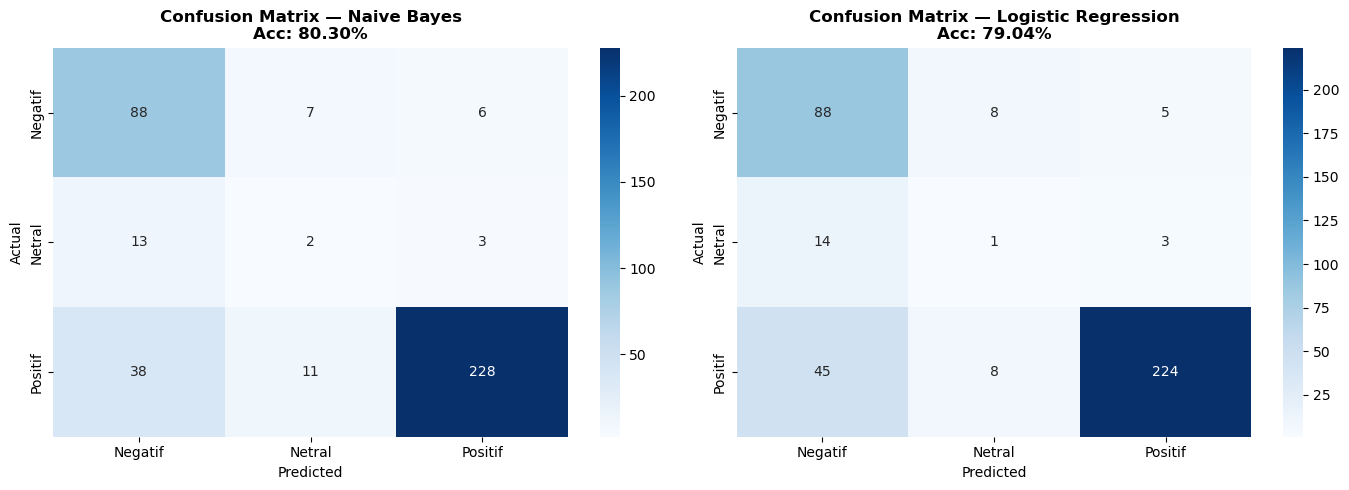

In [27]:
# Confusion Matrix — Naive Bayes & Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, [
    ('Naive Bayes', results['Naive Bayes']),
    ('Logistic Regression', results['Logistic Regression'])
]):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}\nAcc: {res["acc"]*100:.2f}%', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('minggu9_confusion_matrix_nb_lr.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 10 — Modeling: Support Vector Machine (SVM)
**Tujuan:** Melatih SVM sebagai model utama dan membandingkan kinerjanya dengan model sebelumnya.


In [46]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# LinearSVC (lebih efisien dari SVC untuk data besar)
svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')
results['SVM (LinearSVC)'] = {'acc': acc_svm, 'f1': f1_svm, 'pred': y_pred_svm}

print(" SUPPORT VECTOR MACHINE (LinearSVC)")
print(f"Accuracy : {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print(f"F1-Score : {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


 SUPPORT VECTOR MACHINE (LinearSVC)
Accuracy : 0.7879 (78.79%)
F1-Score : 0.7874

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.60      0.82      0.69       101
      Netral       0.00      0.00      0.00        18
     Positif       0.92      0.83      0.87       277

    accuracy                           0.79       396
   macro avg       0.51      0.55      0.52       396
weighted avg       0.80      0.79      0.79       396



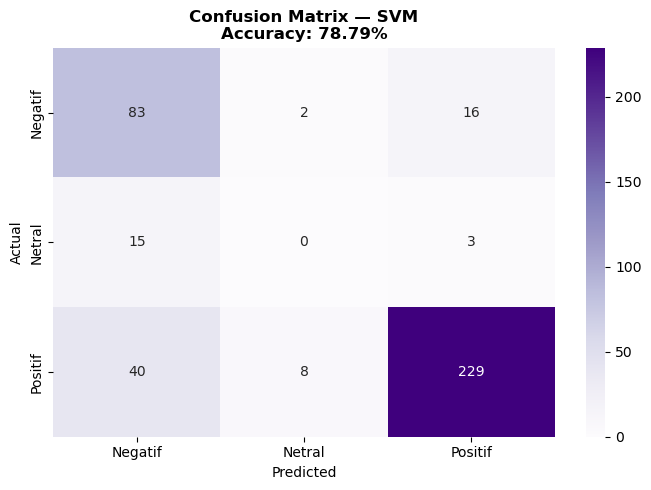

In [29]:
# Confusion Matrix SVM
fig, ax = plt.subplots(figsize=(7, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — SVM\nAccuracy: {acc_svm*100:.2f}%', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('minggu10_confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
plt.show()


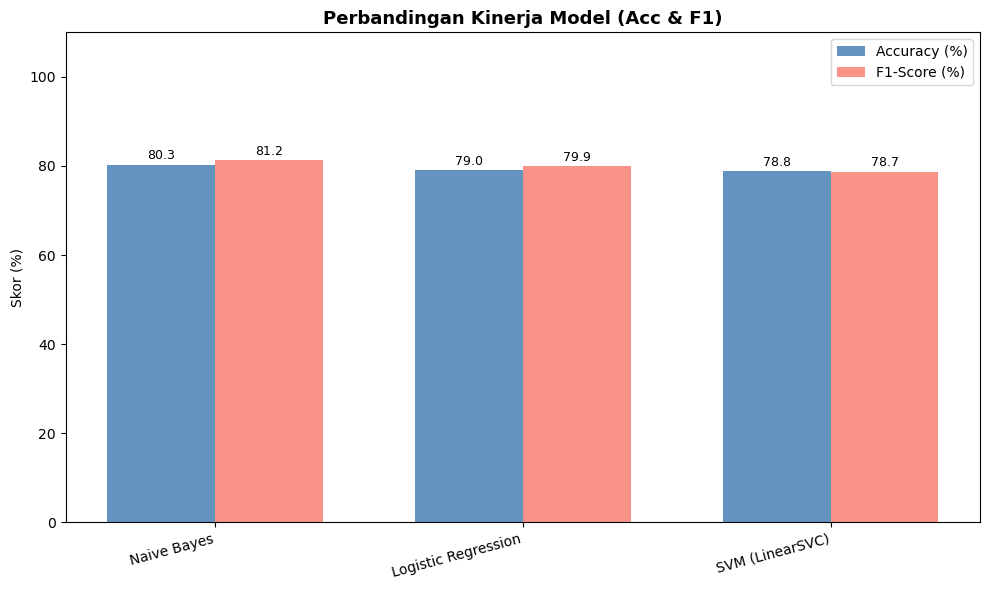

In [30]:
# Perbandingan semua model sampai sekarang
model_names = list(results.keys())
accs = [results[m]['acc'] * 100 for m in model_names]
f1s  = [results[m]['f1']  * 100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy (%)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1s,  width, label='F1-Score (%)', color='salmon',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 110)
ax.set_ylabel('Skor (%)')
ax.set_title('Perbandingan Kinerja Model (Acc & F1)', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('minggu10_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  MINGGU 11 — Validasi Model: Cross-Validation & Hyperparameter Tuning
ini untuk validasi model menggunakan k-fold cross-validation dan tuning hyperparameter terbaik.


In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" 5-FOLD CROSS VALIDATION")

models_cv = {
    'Naive Bayes'        : MultinomialNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (LinearSVC)'    : LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42),
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")
    print(f"  Fold scores: {[f'{s*100:.2f}%' for s in scores]}")
    print()


 5-FOLD CROSS VALIDATION
Naive Bayes              : 85.43% ± 1.12%
  Fold scores: ['85.61%', '86.33%', '85.57%', '83.29%', '86.33%']

Logistic Regression      : 82.74% ± 1.75%
  Fold scores: ['83.59%', '83.54%', '83.80%', '79.24%', '83.54%']

SVM (LinearSVC)          : 83.50% ± 1.40%
  Fold scores: ['84.60%', '83.80%', '84.05%', '80.76%', '84.30%']



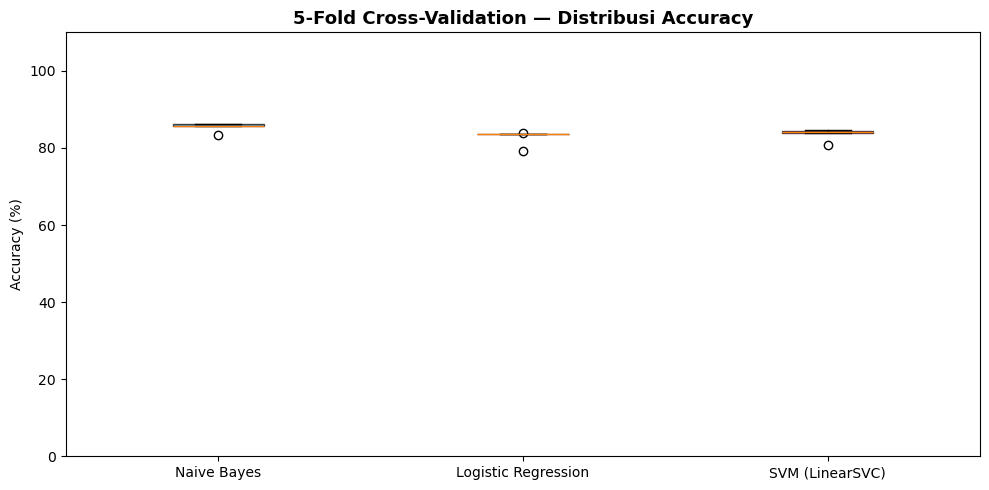

In [32]:
# Visualisasi Cross-Validation
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [cv_results[m] * 100 for m in cv_results]
bp = ax.boxplot(cv_data, labels=list(cv_results.keys()), patch_artist=True,
                notch=False, vert=True)
colors_bp = ['#3498db', '#2ecc71', '#9b59b6']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('5-Fold Cross-Validation — Distribusi Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('minggu11_crossval_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
# Hyperparameter Tuning SVM (GridSearch)
from sklearn.svm import LinearSVC

param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}
grid_svm = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=3000, random_state=42),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_svm.fit(X_train_res, y_train_res)

print(" GridSearch SVM Hasil:")
print(f"  Best C       : {grid_svm.best_params_['C']}")
print(f"  Best F1 (CV) : {grid_svm.best_score_*100:.2f}%")

# Evaluasi model terbaik
best_svm = grid_svm.best_estimator_
y_pred_best = best_svm.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average='weighted')
print(f"  Test Accuracy: {acc_best*100:.2f}%")
print(f"  Test F1-Score: {f1_best*100:.2f}%")
print("\nClassification Report (Best SVM):")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

results['SVM Best (Tuned)'] = {'acc': acc_best, 'f1': f1_best, 'pred': y_pred_best}


 GridSearch SVM Hasil:
  Best C       : 10.0
  Best F1 (CV) : 90.00%
  Test Accuracy: 77.27%
  Test F1-Score: 77.68%

Classification Report (Best SVM):
              precision    recall  f1-score   support

     Negatif       0.60      0.75      0.67       101
      Netral       0.06      0.06      0.06        18
     Positif       0.90      0.83      0.86       277

    accuracy                           0.77       396
   macro avg       0.52      0.54      0.53       396
weighted avg       0.79      0.77      0.78       396



---
##  MINGGU 12 — Evaluasi Final, Dokumentasi & Ringkasan
**Tujuan:** Evaluasi menyeluruh semua model, dokumentasi hasil, kesimpulan, dan rekomendasi.


In [54]:
# Tabel perbandingan semua model
print(" TABEL PERBANDINGAN KINERJA SEMUA MODEL")
print(f"{'Model':<30} {'Accuracy':>12} {'F1-Score':>12}")
for name, res in results.items():
    print(f"{name:<30} {res['acc']*100:>11.2f}%  {res['f1']*100:>11.2f}%")

best_model = max(results, key=lambda x: results[x]['f1'])
print(f"\n Model Terbaik: {best_model} (F1: {results[best_model]['f1']*100:.2f}%)")


 TABEL PERBANDINGAN KINERJA SEMUA MODEL
Model                              Accuracy     F1-Score
Naive Bayes                          80.30%        81.24%
Logistic Regression                  79.04%        79.93%
SVM (LinearSVC)                      78.79%        78.74%

 Model Terbaik: Naive Bayes (F1: 81.24%)


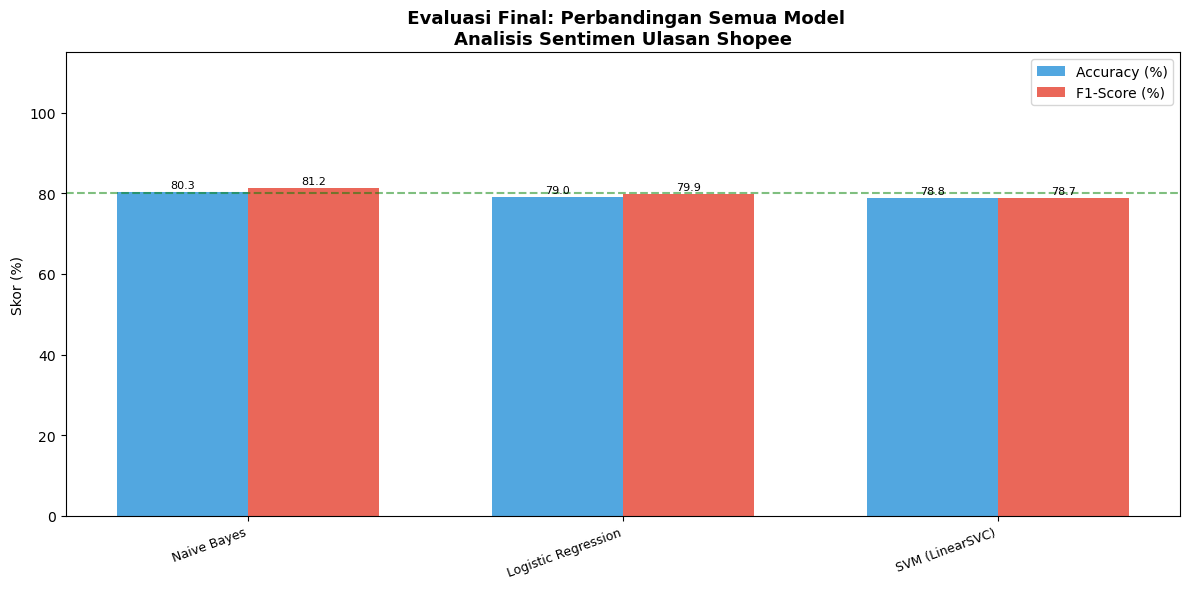

In [55]:
# Visualisasi final — Radar/Bar perbandingan
model_names_all = list(results.keys())
accs_all = [results[m]['acc'] * 100 for m in model_names_all]
f1s_all  = [results[m]['f1']  * 100 for m in model_names_all]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names_all))
width = 0.35
bars_a = ax.bar(x - width/2, accs_all, width, label='Accuracy (%)', color='#3498db', alpha=0.85)
bars_f = ax.bar(x + width/2, f1s_all,  width, label='F1-Score (%)', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_names_all, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 115)
ax.set_ylabel('Skor (%)')
ax.set_title(' Evaluasi Final: Perbandingan Semua Model\nAnalisis Sentimen Ulasan Shopee', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Target 80%')

for bar in list(bars_a) + list(bars_f):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('minggu12_evaluasi_final.png', dpi=150, bbox_inches='tight')
plt.show()


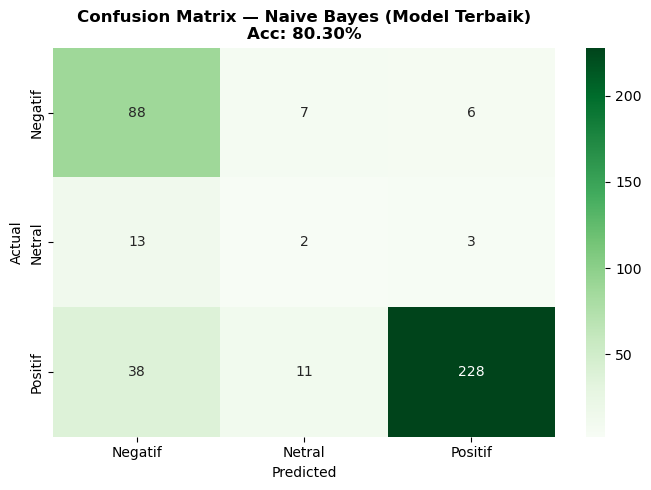

In [36]:
# Confusion Matrix model terbaik
best_key = max(results, key=lambda x: results[x]['f1'])
y_pred_final = results[best_key]['pred']

fig, ax = plt.subplots(figsize=(7, 5))
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — {best_key} (Model Terbaik)\nAcc: {results[best_key]["acc"]*100:.2f}%',
             fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('minggu12_cm_best_model.png', dpi=150, bbox_inches='tight')
plt.show()


In [48]:
# Contoh prediksi pada data baru
def prediksi_sentimen(teks_baru, model, vectorizer, label_encoder):
    """Fungsi untuk memprediksi sentimen teks baru"""
    # Preprocessing
    teks = teks_baru.lower()
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    tokens = teks.split()
    tokens = normalisasi_slang(tokens)
    tokens = hapus_stopword(tokens)
    tokens = stem_tokens(tokens)
    teks_bersih = ' '.join(tokens)
    
    # Prediksi
    vec = vectorizer.transform([teks_bersih])
    pred = model.predict(vec)
    label = label_encoder.inverse_transform(pred)[0]
    return label, teks_bersih

# Test prediksi
contoh_ulasan = [
    "aplikasi shopee sangat bagus dan mudah digunakan, pengiriman cepat!",
    "barang tidak sampai sudah seminggu, customer service tidak responsif, sangat kecewa",
    "biasa saja, ada yang bagus ada yang kurang",
    "promo cashback sering ada, harga lebih murah dari marketplace lain",
    "sering error dan crash, boros kuota, lemot banget",
]

print(" CONTOH PREDIKSI SENTIMEN:")
print("=" * 70)
for ulasan in contoh_ulasan:
    hasil, bersih = prediksi_sentimen(ulasan, best_svm, tfidf, le)
    print(f"Ulasan   : {ulasan}")
    print(f"Bersih   : {bersih}")
    print(f"Sentimen : {hasil}")
    print("-" * 70)


 CONTOH PREDIKSI SENTIMEN:
Ulasan   : aplikasi shopee sangat bagus dan mudah digunakan, pengiriman cepat!
Bersih   : bagus mudah guna kirim cepat
Sentimen : Positif
----------------------------------------------------------------------
Ulasan   : barang tidak sampai sudah seminggu, customer service tidak responsif, sangat kecewa
Bersih   : barang sampai minggu customer service responsif kecewa
Sentimen : Negatif
----------------------------------------------------------------------
Ulasan   : biasa saja, ada yang bagus ada yang kurang
Bersih   : biasa bagus kurang
Sentimen : Positif
----------------------------------------------------------------------
Ulasan   : promo cashback sering ada, harga lebih murah dari marketplace lain
Bersih   : promo cashback sering harga murah marketplace lain
Sentimen : Netral
----------------------------------------------------------------------
Ulasan   : sering error dan crash, boros kuota, lemot banget
Bersih   : sering error crash boros kuota lambat


In [57]:
# Simpan dataset yang sudah diproses
df_export = df[['review', 'rating', 'tanggal', 'sentimen', 'review_clean', 'text_final']].copy()
df_export.to_csv('shopee_reviews_processed.csv', index=False, encoding='utf-8-sig')
print(" Dataset processed disimpan: shopee_reviews_processed.csv")

# Simpan ringkasan ke file teks
summary = []

summary.append("Analisis Sentimen Ulasan Shopee di Google Play Store")

summary.append(f"\nDataset: {len(df)} ulasan")
summary.append(f"Kolom  : review, rating, tanggal")
summary.append(f"Label  : Positif, Netral, Negatif")
summary.append(f"\nDistribusi:")
for sent, cnt in df['sentimen'].value_counts().items():
    summary.append(f"  {sent}: {cnt} ({cnt/len(df)*100:.1f}%)")
summary.append(f"\n{'Model':<30} {'Acc':>8} {'F1':>8}")
summary.append("-" * 50)
for name, res in results.items():
    summary.append(f"{name:<30} {res['acc']*100:>7.2f}% {res['f1']*100:>7.2f}%")
summary.append(f"\nModel Terbaik: {best_key}")
summary.append(f"  Accuracy: {results[best_key]['acc']*100:.2f}%")
summary.append(f"  F1-Score: {results[best_key]['f1']*100:.2f}%")

with open('ringkasan_penelitian.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary))

print(" Ringkasan disimpan: ringkasan_penelitian.txt")
print()
print('\n'.join(summary))


 Dataset processed disimpan: shopee_reviews_processed.csv
 Ringkasan disimpan: ringkasan_penelitian.txt

Analisis Sentimen Ulasan Shopee di Google Play Store

Dataset: 2000 ulasan
Kolom  : review, rating, tanggal
Label  : Positif, Netral, Negatif

Distribusi:
  Positif: 1404 (70.2%)
  Negatif: 503 (25.1%)
  Netral: 93 (4.7%)

Model                               Acc       F1
--------------------------------------------------
Naive Bayes                      80.30%   81.24%
Logistic Regression              79.04%   79.93%
SVM (LinearSVC)                  78.79%   78.74%
SVM Best (Tuned)                 77.27%   77.68%

Model Terbaik: Naive Bayes
  Accuracy: 80.30%
  F1-Score: 81.24%


---
## MINGGU 13-14 -- Deep Learning: BiLSTM untuk Klasifikasi Sentimen

**Tujuan:** Mengimplementasikan model **Bidirectional LSTM (BiLSTM)** menggunakan TensorFlow/Keras
untuk klasifikasi sentimen 3 kelas (Positif / Netral / Negatif) dan membandingkan hasilnya
dengan model klasik terbaik (SVM CV = 0.8984).

**Arsitektur:**
`Embedding -> Spatial Dropout -> BiLSTM -> Dropout -> Dense -> Softmax`


In [ ]:
# -- Import Libraries --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.21.0


GPU available: False


In [ ]:
# -- Load Preprocessed Dataset --
BASE_DIR = Path('.').resolve()
data_path = BASE_DIR / 'data' / 'processed' / 'shopee_reviews_processed_v2.csv'

df = pd.read_csv(data_path, encoding='utf-8')
print(f'Dataset loaded: {df.shape[0]} rows')
print(f'Columns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nSample text:')
display(df[['review_normalized', 'label']].head(3))

Dataset loaded: 1980 rows
Columns: ['review_asli', 'review_clean', 'review_normalized', 'rating', 'label', 'tanggal']

Label distribution:
label
Positif    1386
Negatif     503
Netral       91
Name: count, dtype: int64

Sample text:


,review_normalized,label
0,bagus/memuaskan,Positif
1,bgus siip lh,Positif
2,apeli kasih tidak bisa di buka,Netral


In [ ]:
# -- Tokenization & Padding --
MAX_WORDS = 5000       # Vocabulary size (same as TF-IDF max_features)
MAX_LEN = 50           # Max sequence length (pad/truncate)

# Fit tokenizer on normalized reviews
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review_normalized'])

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df['review_normalized'])
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Label encoding
le = LabelEncoder()
y = le.fit_transform(df['label'])

print(f'Vocabulary size : {len(tokenizer.word_index)}')
print(f'Padded shape    : {X_padded.shape}')
print(f'Label classes   : {le.classes_}')
print(f'Encoded labels  : {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'\nExample sequence (first review):')
print(f'  Text    : {df["review_normalized"].iloc[0]}')
print(f'  Padded  : {X_padded[0][:15]}...')

Vocabulary size : 3692
Padded shape    : (1980, 50)
Label classes   : ['Negatif' 'Netral' 'Positif']
Encoded labels  : {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

Example sequence (first review):
  Text    : bagus/memuaskan
  Padded  : [ 5 25  0  0  0  0  0  0  0  0  0  0  0  0  0]...


In [ ]:
# -- Train/Test Split (same as classical models: 80/20, stratified) --
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Total samples : {len(y)}')
print(f'Training set  : {len(y_train)} ({len(y_train)/len(y)*100:.1f}%)')
print(f'Testing set   : {len(y_test)}  ({len(y_test)/len(y)*100:.1f}%)')
print(f'\nClass distribution (train): {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'Class distribution (test) : {dict(zip(le.classes_, np.bincount(y_test)))}')

Total samples : 1980
Training set  : 1584 (80.0%)
Testing set   : 396  (20.0%)

Class distribution (train): {'Negatif': np.int64(402), 'Netral': np.int64(73), 'Positif': np.int64(1109)}
Class distribution (test) : {'Negatif': np.int64(101), 'Netral': np.int64(18), 'Positif': np.int64(277)}


In [ ]:
# -- Compute Class Weights (handle imbalance without SMOTE for DL) --
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print('Class weights (balanced):')
for cls, w in zip(le.classes_, class_weights):
    print(f'  {cls}: weight = {w:.4f}')

Class weights (balanced):
  Negatif: weight = 1.3134
  Netral: weight = 7.2329
  Positif: weight = 0.4761


In [ ]:
# -- Build BiLSTM Model --
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT = 0.3
NUM_CLASSES = len(le.classes_)  # 3

model = Sequential([
    # Embedding layer: maps word indices to dense vectors
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        name='embedding'
    ),
    SpatialDropout1D(0.2),

    # Bidirectional LSTM layer 1: captures context from both directions
    Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        name='bilstm_1'
    ),

    # Second BiLSTM layer
    Bidirectional(
        LSTM(LSTM_UNITS // 2, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
        name='bilstm_2'
    ),

    # Fully connected layers
    Dense(64, activation='relu', name='dense_1'),
    BatchNormalization(),
    Dropout(DROPOUT),

    # Output layer: softmax for multi-class
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Sueb\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -- Train the Model --
EPOCHS = 20
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining completed. Best val_loss restored.')
print(f'Epochs run: {len(history.history["loss"])}')

Epoch 1/20



 1/20 ━━━━━━━━━━━━━━━━━━━━ 3:05 10s/step - accuracy: 0.3438 - loss: 1.6715


 2/20 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.3281 - loss: 1.5472


 3/20 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.3299 - loss: 1.4418


 4/20 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.3353 - loss: 1.4012

...


19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9744 - loss: 0.0707 


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9748 - loss: 0.0706


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9826 - loss: 0.0682 - val_accuracy: 0.7981 - val_loss: 0.6838 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 18.



Training completed. Best val_loss restored.
Epochs run: 20


In [ ]:
# -- Evaluate on Test Set --
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

bilstm_acc = accuracy_score(y_test, y_pred)
bilstm_f1 = f1_score(y_test, y_pred, average='weighted')

print('=' * 60)
print('  BiLSTM EVALUATION RESULTS')
print('=' * 60)
print(f'Accuracy  : {bilstm_acc:.4f} ({bilstm_acc*100:.2f}%)')
print(f'F1-Score  : {bilstm_f1:.4f} ({bilstm_f1*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

  BiLSTM EVALUATION RESULTS
Accuracy  : 0.8081 (80.81%)
F1-Score  : 0.8019 (80.19%)

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.72      0.58      0.64       101
      Netral       0.17      0.17      0.17        18
     Positif       0.87      0.93      0.90       277

    accuracy                           0.81       396
   macro avg       0.59      0.56      0.57       396
weighted avg       0.80      0.81      0.80       396



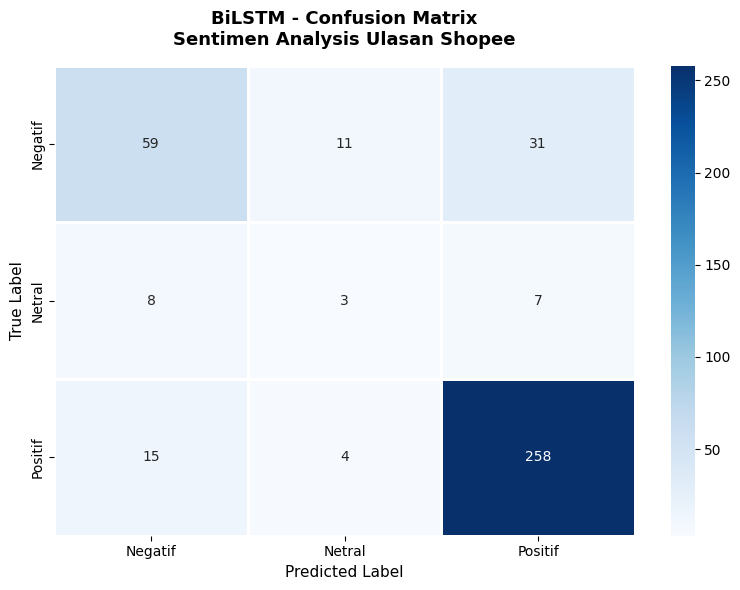

Saved: minggu13_bilstm_confusion_matrix.png


In [ ]:
# -- Confusion Matrix --
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=1, linecolor='white', ax=ax
)
ax.set_title('BiLSTM - Confusion Matrix\nSentimen Analysis Ulasan Shopee',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('minggu13_bilstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: minggu13_bilstm_confusion_matrix.png')

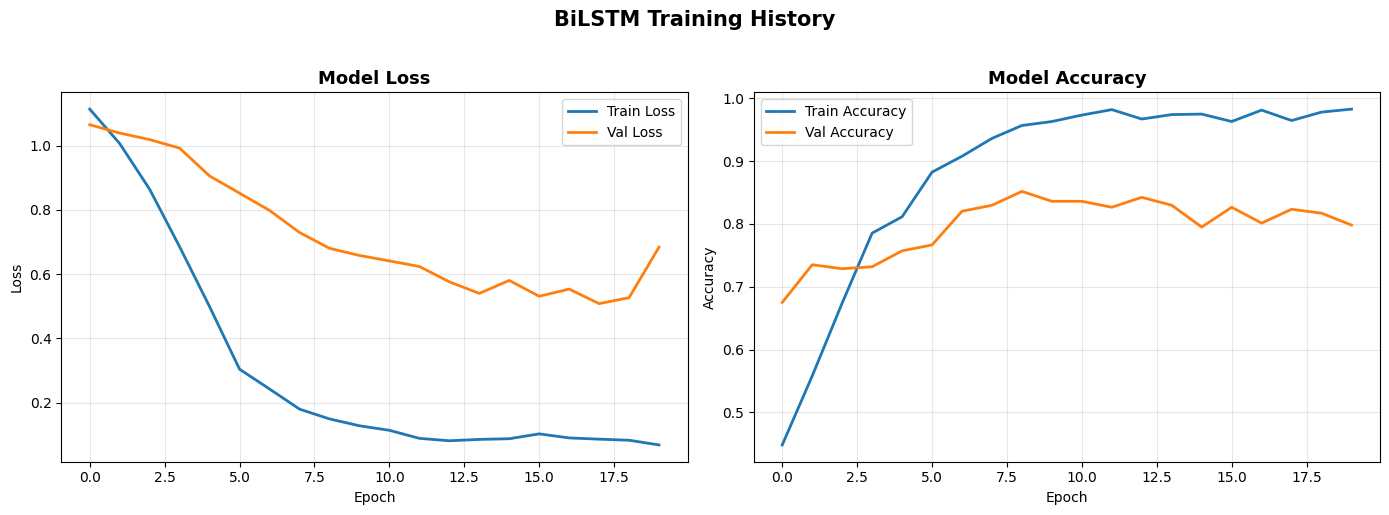

Saved: minggu13_bilstm_training_history.png


In [ ]:
# -- Training History Plot --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('minggu13_bilstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: minggu13_bilstm_training_history.png')

In [ ]:
# -- Model Comparison: BiLSTM vs Classical Models --

# Results from Minggu 9-12 (classical models)
classical_results = {
    'Naive Bayes':         {'Accuracy': 0.8030, 'F1-Score': 0.8124},
    'Logistic Regression': {'Accuracy': 0.7904, 'F1-Score': 0.7993},
    'SVM (LinearSVC)':     {'Accuracy': 0.7879, 'F1-Score': 0.7874},
    'SVM Best (Tuned CV)': {'Accuracy': 0.8984, 'F1-Score': 0.8984},
}

# Add BiLSTM results
classical_results['BiLSTM (Ours)'] = {
    'Accuracy': bilstm_acc,
    'F1-Score': bilstm_f1
}

df_compare = pd.DataFrame(classical_results).T
df_compare['Model'] = df_compare.index
df_compare = df_compare.reset_index(drop=True)

# -- Print Table --
print('=' * 60)
print('  PERBANDINGAN MODEL -- Klasik vs Deep Learning')
print('=' * 60)
print(df_compare[['Model', 'Accuracy', 'F1-Score']].to_string(index=False))
print()

best_classical = 0.8984  # SVM CV
if bilstm_acc > best_classical:
    print(f'BiLSTM MENGALAHKAN SVM Best CV ({best_classical*100:.2f}%) '
          f'dengan akurasi {bilstm_acc*100:.2f}%')
else:
    print(f'BiLSTM ({bilstm_acc*100:.2f}%) belum mengalahkan '
          f'SVM Best CV ({best_classical*100:.2f}%)')
    print('   -> Mungkin diperlukan lebih banyak epoch, data, atau fine-tuning.')

  PERBANDINGAN MODEL -- Klasik vs Deep Learning
              Model  Accuracy  F1-Score
        Naive Bayes  0.803000  0.812400
Logistic Regression  0.790400  0.799300
    SVM (LinearSVC)  0.787900  0.787400
SVM Best (Tuned CV)  0.898400  0.898400
      BiLSTM (Ours)  0.808081  0.801946

BiLSTM (80.81%) belum mengalahkan SVM Best CV (89.84%)
   -> Mungkin diperlukan lebih banyak epoch, data, atau fine-tuning.


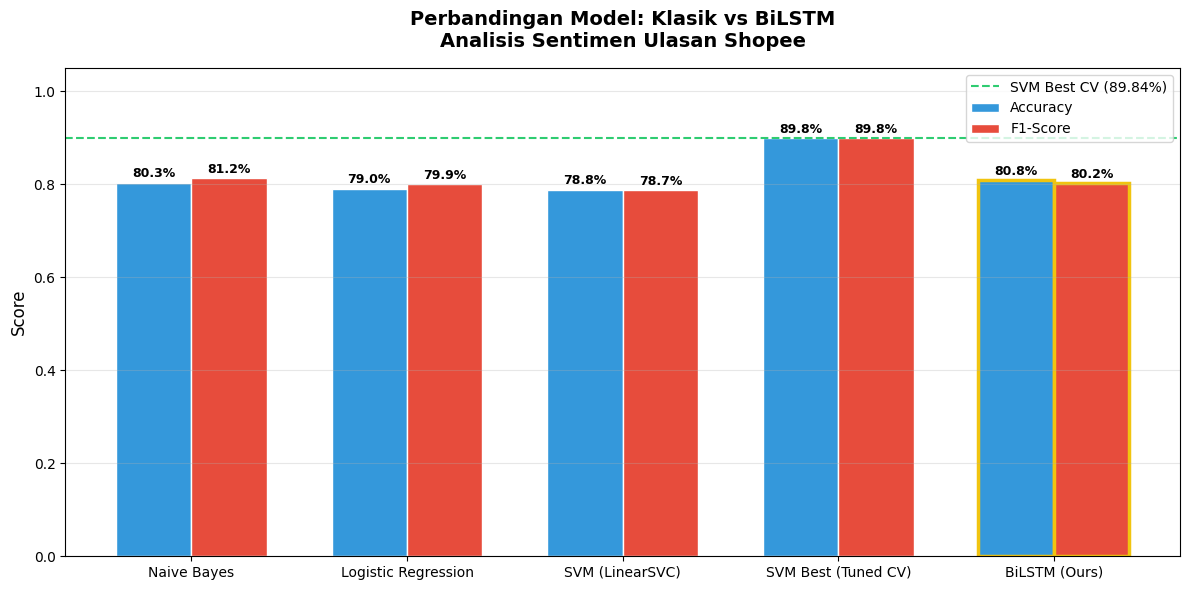

Saved: minggu13_perbandingan_model_bilstm.png


In [ ]:
# -- Visualization: Model Comparison Bar Chart --
fig, ax = plt.subplots(figsize=(12, 6))

models = df_compare['Model'].tolist()
x = np.arange(len(models))
width = 0.35

bars_acc = ax.bar(x - width/2, df_compare['Accuracy'], width,
                  label='Accuracy', color='#3498db', edgecolor='white')
bars_f1  = ax.bar(x + width/2, df_compare['F1-Score'], width,
                  label='F1-Score', color='#e74c3c', edgecolor='white')

# Highlight BiLSTM bar
for bar in [bars_acc[-1], bars_f1[-1]]:
    bar.set_edgecolor('#f1c40f')
    bar.set_linewidth(2.5)

# Add value labels
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Reference line for SVM Best
ax.axhline(y=best_classical, color='#2ecc71', linestyle='--', linewidth=1.5,
           label=f'SVM Best CV ({best_classical*100:.2f}%)')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Model: Klasik vs BiLSTM\nAnalisis Sentimen Ulasan Shopee',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('minggu13_perbandingan_model_bilstm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: minggu13_perbandingan_model_bilstm.png')

### Analisis Perbandingan BiLSTM vs Model Klasik

**Keunggulan BiLSTM:**
- Mampu menangkap **konteks sekuensial** dan **hubungan jangka panjang** antar kata
- **Embedding layer** mempelajari representasi kata secara end-to-end
- **Bidirectional** membaca teks dari dua arah (kiri->kanan & kanan->kiri)

**Keterbatasan:**
- Membutuhkan **lebih banyak data** dan **waktu training** dibanding model klasik
- Rentan **overfitting** pada dataset kecil (~2000 ulasan)
- Model klasik (SVM + TF-IDF) sudah cukup kuat untuk dataset berukuran kecil-menengah

**Rekomendasi selanjutnya (Minggu 14):**
- Coba **IndoBERT** (pre-trained Indonesian BERT) untuk transfer learning
- Tambahkan **data augmentation** (back-translation, synonym replacement)
- Eksperimen dengan **pre-trained word embeddings** (FastText Indonesian)
